In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
device

device(type='cuda', index=0)

In [4]:
data_dir = 'PetImages'
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [5]:
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=16, shuffle=True, num_workers=4) for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

In [6]:
from tqdm import tqdm
# use tqdm.auto for notebook
def train(model,criterion,optimizer,dataloaders,dataset_sizes,device):
    model.train()
    running_loss = 0.0
    
    for inputs, labels in tqdm(dataloaders['train']):
        inputs,labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / dataset_sizes['train']
    print(f'Train Loss: {epoch_loss:.4f}')
    return epoch_loss

In [13]:
def validate(model,dataloaders,dataset_size,criterion,device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloaders['val']):
            inputs,labels = inputs.to(device),labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _,predicted = torch.max(outputs.data,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    epoch_loss = running_loss/dataset_size['val']
    accuracy = correct/total

    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')

    conf_matrix = confusion_matrix(all_labels, all_preds)
    
    print(f'Validation Loss: {epoch_loss:.4f}, Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}')
    print(f'Confusion Matrix:\n{conf_matrix}') 
    return epoch_loss, accuracy, precision, recall, f1, conf_matrix


In [14]:
import torch
import torchvision.models as models
from torchvision.models import ResNet18_Weights

weights_path = "C:/Users/awael/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth"

In [15]:
model_ft = models.resnet18()
model_ft.load_state_dict(torch.load(weights_path))
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.0001, momentum=0.9)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

Epoch 1/25
----------


100%|████████████████████████████████████████████████████████████████████████████████| 250/250 [03:13<00:00,  1.29it/s]


Train Loss: 0.0250


100%|██████████████████████████████████████████████████████████████████████████████████| 63/63 [00:19<00:00,  3.28it/s]


Validation Loss: 0.0079, Accuracy: 0.9720
Precision: 0.9720, Recall: 0.9720, F1 Score: 0.9720
Confusion Matrix:
[[485  15]
 [ 13 487]]
Epoch 2/25
----------


...

Validation Loss: 0.0016, Accuracy: 0.9910
Precision: 0.9910, Recall: 0.9910, F1 Score: 0.9910
Confusion Matrix:
[[496   4]
 [  5 495]]
Epoch 25/25
----------


100%|████████████████████████████████████████████████████████████████████████████████| 250/250 [03:16<00:00,  1.27it/s]


Train Loss: 0.0067


100%|██████████████████████████████████████████████████████████████████████████████████| 63/63 [00:21<00:00,  2.98it/s]
C:\Users\awael\AppData\Local\Temp\ipykernel_3776\1375829951.py:70: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


Validation Loss: 0.0017, Accuracy: 0.9890
Precision: 0.9890, Recall: 0.9890, F1 Score: 0.9890
Confusion Matrix:
[[493   7]
 [  4 496]]
Training complete in 92m 44s
Best Validation Accuracy: 0.9920
Best Precision: 0.9920
Best Recall: 0.9920
Best F1 Score: 0.9920


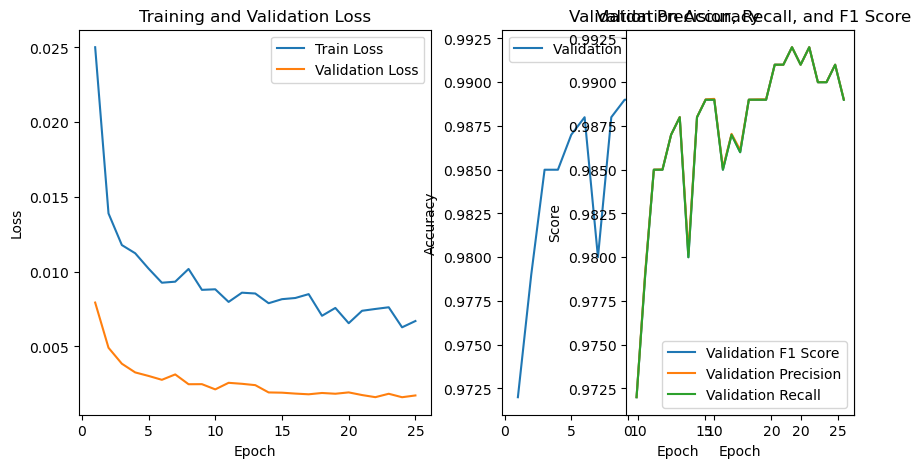

In [16]:
num_epochs = 25
train_losses = []
val_losses = []
val_accuracies = []
val_precisions = []
val_recalls = []
val_f1s = []

best_f1 = 0.0
best_precision = 0.0
best_recall = 0.0
best_accuracy = 0.0

start_time = time.time()


for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    print('-' * 10)

    train_loss = train(model_ft, criterion, optimizer_ft, dataloaders, dataset_sizes, device)
    val_loss, val_accuracy, precision, recall, f1, conf_matrix = validate(model_ft, dataloaders, dataset_sizes, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    val_precisions.append(precision)
    val_recalls.append(recall)
    val_f1s.append(f1)

    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        best_f1 = f1
        best_precision = precision
        best_recall = recall

end_time = time.time()
total_time = end_time - start_time
print(f'Training complete in {total_time // 60:.0f}m {total_time % 60:.0f}s')
print(f'Best Validation Accuracy: {best_accuracy:.4f}')
print(f'Best Precision: {best_precision:.4f}')
print(f'Best Recall: {best_recall:.4f}')
print(f'Best F1 Score: {best_f1:.4f}')

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(range(1, num_epochs + 1), val_f1s, label='Validation F1 Score')
plt.plot(range(1, num_epochs + 1), val_precisions, label='Validation Precision')
plt.plot(range(1, num_epochs + 1), val_recalls, label='Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Validation Precision, Recall, and F1 Score')
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
torch.save(model_ft.state_dict(), 'model_ft1.pth')